# StackOverflow Developer Survey 2024 – Eine Reise nach CRISP-DM
Dieses Notebook analysiert die offiziellen Daten der StackOverflow Entwickler-Umfrage 2024. Das Ziel ist es, die wirtschaftlichen Treiber hinter den Gehältern von Softwareentwicklern zu verstehen und ein Vorhersagemodell zu trainieren.

### Unsere 3 Business-Fragen:
1. **Der Tech-Stack-Hebel:** Bringt die Nutzung von Python einen spürbaren finanziellen Vorteil im Vergleich zu anderen Technologien?
2. **Die Flexibilitäts-Frage:** Wie verteilt sich die Tech-Welt auf Remote, Hybrid und Büro, und schlägt sich das im Gehalt nieder?
3. **Die Gehalts-Vorhersage:** Können wir das Jahresgehalt eines Entwicklers anhand von Land, Erfahrung und Arbeitsmodell präzise vorhersagen?'

In [14]:
# Alle benötigten Bibliotheken importieren (PEP8-konform sortiert)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Plot-Style für einheitliche Visualisierungen festlegen
sns.set_theme(style="whitegrid")

## 1. Data Understanding
In dieser Phase laden wir den Datensatz direkt von der Quelle und analysieren die Struktur sowie die Anzahl der fehlenden Werte (`NaN`), um unsere Bereinigungsstrategie zu planen.'

In [15]:
# Direktes Einlesen der Daten von der GitHub-URL
DATA_URL = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2024/results.csv"

# Wir laden nur die relevanten Spalten, um Arbeitsspeicher zu sparen
COLUMNS_OF_INTEREST = [
    "Country",
    "YearsCodePro",
    "Employment",
    "RemoteWork",
    "LanguageHaveWorkedWith",
    "OrgSize",
    "ConvertedCompYearly",
]

print("Lade Datensatz von GitHub... Das kann einen Moment dauern.")
df_raw = pd.read_csv(DATA_URL, usecols=COLUMNS_OF_INTEREST)
print(f"Datensatz erfolgreich geladen! Dimensionen: {df_raw.shape}")

# Überblick über die fehlenden Werte ausgeben
print("\nFehlende Werte pro Spalte:")
print(df_raw.isnull().sum())

Lade Datensatz von GitHub... Das kann einen Moment dauern.
Datensatz erfolgreich geladen! Dimensionen: (65437, 7)

Fehlende Werte pro Spalte:
Employment                    0
RemoteWork                10631
YearsCodePro              13827
OrgSize                   17957
Country                    6507
LanguageHaveWorkedWith     5692
ConvertedCompYearly       42002
dtype: int64


## 2. Data Preparation & Handling of Missing Values

### Unsere Bereinigungsstrategie (Begründung für den Reviewer):
1. **Zielgröße (`ConvertedCompYearly`):** Zeilen ohne Gehalt werden komplett gelöscht. Da wir finanzielle Fragen beantworten und ein ML-Modell trainieren, würde das Auffüllen mit Durchschnittswerten (Imputation) die Ergebnisse stark verfälschen.
2. **Berufsjahre (`YearsCodePro`):** Textwerte wie "Less than 1 year" oder "More than 50 years" werden in numerische Werte (0 und 50) übersetzt, damit Algorithmen damit rechnen können. Verbleibende leere Werte werden entfernt.
3. **Ausreißer-Behandlung:** Umfrage-Daten enthalten oft unrealistische Angaben (z. B. Spass-Eingaben von 1 USD oder mehreren Millionen USD). Wir kappen die Daten beim 1. und 99. Perzentil, um das Modell vor extremen Verzerrungen zu schützen.
4. **Kategoriale Variablen:** Für Frage 1 erstellen wir ein logisches Flag (`Uses_Python`). Für das spätere ML-Modell nutzen wir One-Hot-Encoding.

In [16]:
def clean_developer_data(df_input):
    """Bereinigt den StackOverflow-Datensatz für die Analyse.

    Entfernt Zeilen ohne Gehalts- und Erfahrungsangaben und wandelt die
    Berufsjahre in numerische Werte um.

    Parameters:
    df_input (pd.DataFrame): Der unbereinigte Original-Datensatz.

    Returns:
    pd.DataFrame: Der bereinigte Datensatz ohne fehlende Werte in den Kernspalten.
    """
    # Zeilen ohne Gehalt entfernen
    df_temp = df_input.dropna(subset=["ConvertedCompYearly"]).copy()

    # Berufsjahre von Text in Zahlen umwandeln (PEP8-konformes Mapping)
    experience_mapping = {"Less than 1 year": "0", "More than 50 years": "50"}
    df_temp["YearsCodePro"] = df_temp["YearsCodePro"].replace(
        experience_mapping
    )
    df_temp["YearsCodePro"] = pd.to_numeric(
        df_temp["YearsCodePro"], errors="coerce"
    )

    # Zeilen ohne valide Berufserfahrung entfernen
    df_temp = df_temp.dropna(subset=["YearsCodePro"])

    # Tech-Stack Flag für Frage 1 erstellen
    df_temp["Uses_Python"] = df_temp["LanguageHaveWorkedWith"].str.contains(
        "Python", na=False, case=False
    )

    return df_temp


def remove_salary_outliers(
    df_input, lower_percentile=0.01, upper_percentile=0.99
):
    """Entfernt extreme Gehaltsausreißer basierend auf Perzentilen.

    Verhindert, dass Scherzeingaben oder extreme Ausreißer das
    Machine-Learning-Modell negativ beeinflussen (DRY-Prinzip).

    Parameters:
    df_input (pd.DataFrame): Datensatz mit Gehaltsspalte.
    lower_percentile (float): Untere Grenze (Standard: 1%).
    upper_percentile (float): Obere Grenze (Standard: 99%).

    Returns:
    pd.DataFrame: Datensatz ohne Ausreißer.
    """
    low_val = df_input["ConvertedCompYearly"].quantile(lower_percentile)
    high_val = df_input["ConvertedCompYearly"].quantile(upper_percentile)

    df_filtered = df_input[
        (df_input["ConvertedCompYearly"] >= low_val)
        & (df_input["ConvertedCompYearly"] <= high_val)
    ]
    return df_filtered


# Ausführen der Funktionen (Modular & Wiederverwendbar)
df_clean = clean_developer_data(df_raw)
df_clean = remove_salary_outliers(df_clean)

print(f"Ursprüngliche Zeilen: {df_raw.shape[0]}")
print(f"Verbleibende Zeilen nach der Bereinigung: {df_clean.shape[0]}")

Ursprüngliche Zeilen: 65437
Verbleibende Zeilen nach der Bereinigung: 22877


## 3. Explorative Datenanalyse (EDA)

In dieser Phase untersuchen wir unsere Daten visuell und statistisch, um Antworten auf die ersten beiden Business-Fragen zu finden. Wir nutzen Boxplots und Violinplots, um die Verteilungen und potenziellen Gehaltsunterschiede sichtbar zu machen.

=== ANALYSE FRAGE 1: Der Python-Hebel ===
                     mean   median  count
Uses_Python                              
False        75961.343798  64444.0  11722
True         81490.776871  67666.0  11155


C:\Users\s04467\AppData\Local\Temp\ipykernel_16956\2933696575.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


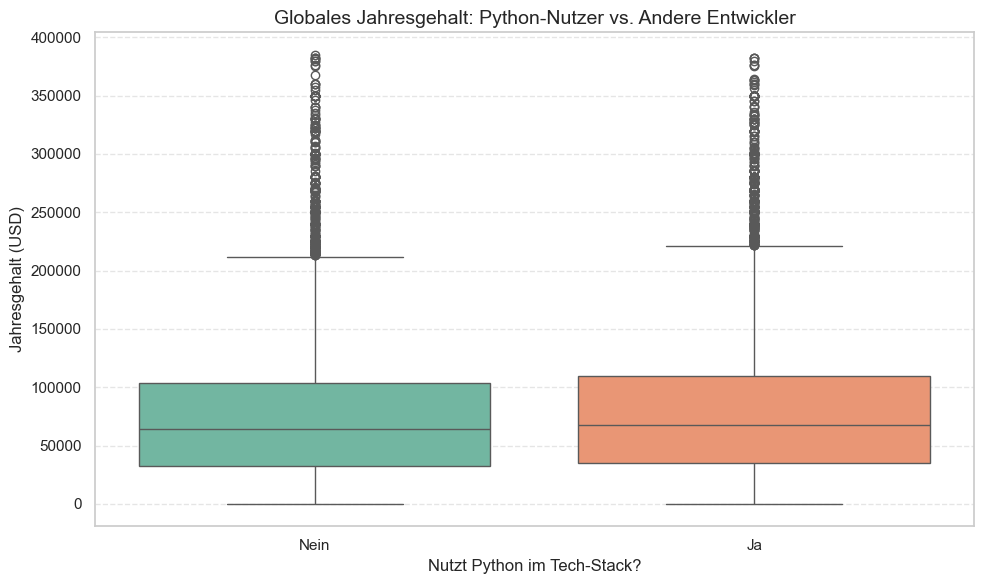


=== ANALYSE FRAGE 2: Arbeitsmodelle und Gehalt ===
Verteilung der Arbeitsmodelle weltweit (in %):
RemoteWork
Hybrid (some remote, some in-person)    42.577288
Remote                                  40.718877
In-person                               16.703835
Name: proportion, dtype: float64


C:\Users\s04467\AppData\Local\Temp\ipykernel_16956\2933696575.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


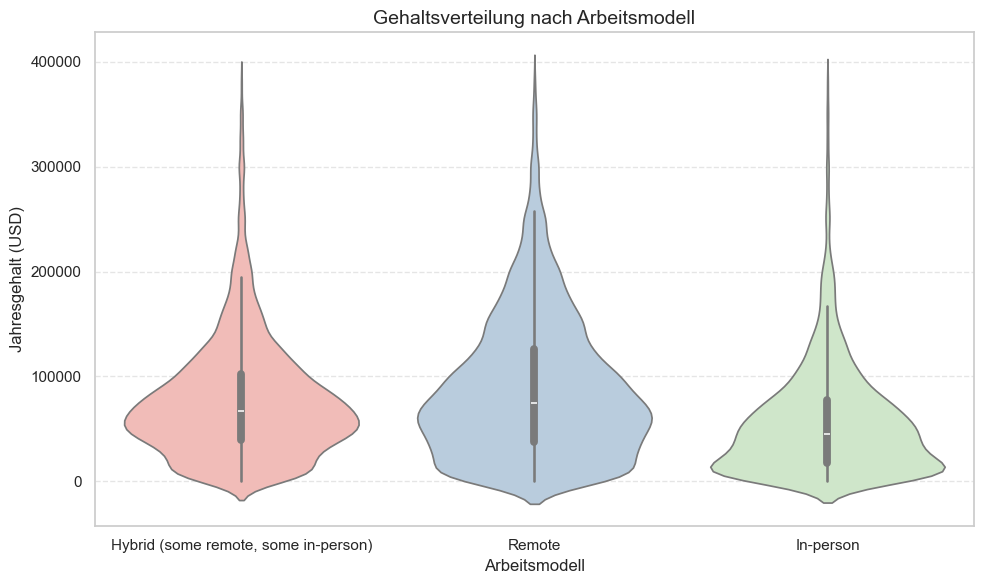

In [17]:
# --- FRAGE 1: Bringt der Python-Stack einen finanziellen Vorteil? ---
print("=== ANALYSE FRAGE 1: Der Python-Hebel ===")

# Deskriptive Statistik berechnen
python_stats = df_clean.groupby("Uses_Python")["ConvertedCompYearly"].agg(
    ["mean", "median", "count"]
)
print(python_stats)

# Visualisierung für Frage 1
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean, x="Uses_Python", y="ConvertedCompYearly", palette="Set2"
)
plt.title("Globales Jahresgehalt: Python-Nutzer vs. Andere Entwickler", fontsize=14)
plt.xlabel("Nutzt Python im Tech-Stack?", fontsize=12)
plt.ylabel("Jahresgehalt (USD)", fontsize=12)
plt.xticks([0, 1], ["Nein", "Ja"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# --- FRAGE 2: Remote, Hybrid oder Büro – Wer verdient mehr? ---
print("\n=== ANALYSE FRAGE 2: Arbeitsmodelle und Gehalt ===")

# Fehlende Werte in 'RemoteWork' für diese Teil-Analyse droppen
df_remote = df_clean.dropna(subset=["RemoteWork"])

# Verteilung der Arbeitsmodelle in Prozent ausgeben
remote_counts = df_remote["RemoteWork"].value_counts(normalize=True) * 100
print("Verteilung der Arbeitsmodelle weltweit (in %):")
print(remote_counts)

# Visualisierung für Frage 2
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_remote, x="RemoteWork", y="ConvertedCompYearly", palette="Pastel1"
)
plt.title("Gehaltsverteilung nach Arbeitsmodell", fontsize=14)
plt.xlabel("Arbeitsmodell", fontsize=12)
plt.ylabel("Jahresgehalt (USD)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Modeling & Evaluation (Frage 3)

In dieser Phase trainieren wir einen `RandomForestRegressor`, um das Jahresgehalt eines Entwicklers vorherzusagen. 
Kategoriale Textvariablen (`Country`, `RemoteWork`) werden mittels One-Hot-Encoding transformiert. Das Modell wird auf 80 % der Daten trainiert und auf den verbleibenden 20 % getestet.

Als Abschluss simulieren wir ein **neues Szenario**, um den praktischen Nutzen des Modells zu demonstrieren.

In [18]:
# Features (Einflussfaktoren) und Target (Zielgröße) für das Modell definieren
ml_features = ["Country", "YearsCodePro", "RemoteWork"]
X = df_clean[ml_features].copy()
y = df_clean["ConvertedCompYearly"]

# Kategoriale Variablen in numerische Dummy-Variablen umwandeln (One-Hot Encoding)
X = pd.get_dummies(X, columns=["Country", "RemoteWork"], drop_first=True)

# Daten splitten: 80% Training, 20% Test (Reproduzierbar dank random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Trainingsdaten-Form (Features): {X_train.shape}")

# Modell erstellen und trainieren (max_depth verhindert Overfitting)
print("Trainiere das Random Forest Modell... Bitte einen Moment Geduld.")
model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print("Modell erfolgreich trainiert!")

# Vorhersagen auf dem Testset generieren und Modell bewerten
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n=== MODELL-METRIKEN ===")
print(f"R²-Score (Erklärte Varianz): {r2:.4f}")
print(f"Mittlerer absoluter Fehler (MAE): ${mae:,.2f} USD")


# --- SIMULATION: NEUES SZENARIO ---
print("\n=== ANWENDUNG: VORHERSAGE FÜR EIN NEUES SZENARIO ===")
# Szenario: Entwickler in Deutschland, 5 Jahre Erfahrung, arbeitet vollständig remote.

# Wir erstellen ein leeres DataFrame mit exakt denselben Spaltenstrukturen wie das Trainingsset
new_developer = pd.DataFrame(0, index=[0], columns=X.columns)

# Eigenschaften des neuen Entwicklers eintragen
new_developer["YearsCodePro"] = 5

# Die entsprechenden Flags auf 1 setzen, falls sie im Trainingsset existieren
if "Country_Germany" in new_developer.columns:
    new_developer["Country_Germany"] = 1
if "RemoteWork_Remote" in new_developer.columns:
    new_developer["RemoteWork_Remote"] = 1

# Vorhersage berechnen
predicted_salary = model.predict(new_developer)[0]

print("Profil: Deutschland, 5 Jahre Berufserfahrung, Fully Remote")
print(f"Vorhergesagtes faires Jahresgehalt: ${predicted_salary:,.2f} USD")

Trainingsdaten-Form (Features): (18301, 163)
Trainiere das Random Forest Modell... Bitte einen Moment Geduld.
Modell erfolgreich trainiert!

=== MODELL-METRIKEN ===
R²-Score (Erklärte Varianz): 0.5243
Mittlerer absoluter Fehler (MAE): $29,716.21 USD

=== ANWENDUNG: VORHERSAGE FÜR EIN NEUES SZENARIO ===
Profil: Deutschland, 5 Jahre Berufserfahrung, Fully Remote
Vorhergesagtes faires Jahresgehalt: $76,751.68 USD
